# Descriptive Statistics

This notebook provides a practical introduction to Descriptive Statistics.

We will calculate statistics manually and with Python, inspect distributions, and visualize data.

> **Learning rule:** understand the calculation first, then use a library to perform it efficiently.


## 1. What is Descriptive Statistics?

Descriptive Statistics summarizes and presents the important characteristics of observed data.

The main areas covered here are:

- Central tendency
- Dispersion
- Quartiles and percentiles
- Frequency distributions
- Distribution shape
- Data visualization


## 2. Main parts of Descriptive Statistics

![Descriptive Statistics](https://media.geeksforgeeks.org/wp-content/uploads/20250508115106881109/descriptive_statistics.webp)

Source: [GeeksforGeeks — Descriptive Statistics](https://www.geeksforgeeks.org/maths/descriptive-statistics/)


## 3. Create a sample dataset

We will use a small marks dataset throughout the notebook.


In [24]:
marks = [45, 50, 55, 60, 60, 65, 70, 75, 80, 95]

print("Data:", marks)
print("Number of observations:", len(marks))


Data: [45, 50, 55, 60, 60, 65, 70, 75, 80, 95]
Number of observations: 10


## 4. Mean

The mean is:

mean = sum of observations / number of observations

Let's calculate it manually.


In [25]:
total = sum(marks)
n = len(marks)

mean_manual = total / n

print("Sum:", total)
print("Number of observations:", n)
print("Mean:", mean_manual)


Sum: 655
Number of observations: 10
Mean: 65.5


## 5. Median

The median is the middle value after sorting the observations.

For an even number of observations, it is the average of the two middle values.


In [26]:
sorted_marks = sorted(marks)

print("Sorted data:", sorted_marks)

middle_left = sorted_marks[len(sorted_marks)//2 - 1]
middle_right = sorted_marks[len(sorted_marks)//2]

median_manual = (middle_left + middle_right) / 2

print("Middle values:", middle_left, "and", middle_right)
print("Median:", median_manual)


Sorted data: [45, 50, 55, 60, 60, 65, 70, 75, 80, 95]
Middle values: 60 and 65
Median: 62.5


## 6. Mode

The mode is the most frequent value.

Here we use Python's `statistics` module to inspect the frequency.


In [27]:
from collections import Counter

frequency = Counter(marks)

print("Frequency:", frequency)
print("Most common:", frequency.most_common())


Frequency: Counter({60: 2, 45: 1, 50: 1, 55: 1, 65: 1, 70: 1, 75: 1, 80: 1, 95: 1})
Most common: [(60, 2), (45, 1), (50, 1), (55, 1), (65, 1), (70, 1), (75, 1), (80, 1), (95, 1)]


## 7. Mean, median and mode using `statistics`



In [28]:
import statistics

print("Mean:", statistics.mean(marks))
print("Median:", statistics.median(marks))

try:
    print("Mode:", statistics.mode(marks))
except statistics.StatisticsError as e:
    print("Mode error:", e)


Mean: 65.5
Median: 62.5
Mode: 60


## 8. Weighted Mean

Suppose marks and their weights are:

- Mathematics: 80, weight 4
- Statistics: 70, weight 3
- Python: 90, weight 2

Formula:

weighted mean = Σ(wx) / Σw


In [29]:
values = [80, 70, 90]
weights = [4, 3, 2]

weighted_mean = sum(x*w for x, w in zip(values, weights)) / sum(weights)

print("Weighted mean:", weighted_mean)


Weighted mean: 78.88888888888889


## 9. Range

Range = maximum − minimum


In [30]:
data_range = max(marks) - min(marks)

print("Maximum:", max(marks))
print("Minimum:", min(marks))
print("Range:", data_range)


Maximum: 95
Minimum: 45
Range: 50


## 10. Variance and Standard Deviation

Population variance divides by N.

Sample variance divides by n − 1.

Python's `statistics.pvariance()` and `statistics.variance()` make the distinction explicit.


In [31]:
population_variance = statistics.pvariance(marks)
sample_variance = statistics.variance(marks)

population_sd = statistics.pstdev(marks)
sample_sd = statistics.stdev(marks)

print("Population variance:", population_variance)
print("Sample variance:", sample_variance)
print("Population standard deviation:", population_sd)
print("Sample standard deviation:", sample_sd)


Population variance: 202.25
Sample variance: 224.72222222222223
Population standard deviation: 14.221462653327892
Sample standard deviation: 14.990737881179239


## 11. Manual variance calculation

Let's see what happens step by step.

1. Calculate the mean.
2. Find each deviation from the mean.
3. Square each deviation.
4. Add the squared deviations.
5. Divide by N for population variance.


In [32]:
mean_value = statistics.mean(marks)

deviations = [x - mean_value for x in marks]
squared_deviations = [d**2 for d in deviations]

print("Mean:", mean_value)
print("Deviations:", deviations)
print("Squared deviations:", squared_deviations)

population_variance_manual = sum(squared_deviations) / len(marks)

print("Population variance:", population_variance_manual)


Mean: 65.5
Deviations: [-20.5, -15.5, -10.5, -5.5, -5.5, -0.5, 4.5, 9.5, 14.5, 29.5]
Squared deviations: [420.25, 240.25, 110.25, 30.25, 30.25, 0.25, 20.25, 90.25, 210.25, 870.25]
Population variance: 202.25


## 12. Mean Absolute Deviation

MAD around the mean:

MAD = Σ|x − mean| / n


In [33]:
mad = sum(abs(x - mean_value) for x in marks) / len(marks)

print("Mean absolute deviation:", mad)


Mean absolute deviation: 11.6


## 13. Quartiles and IQR

Q1 represents the lower quartile.
Q2 is the median.
Q3 represents the upper quartile.

**IQR = Q3 − Q1**.

NumPy provides percentile calculations.


In [34]:
import numpy as np

q1 = np.percentile(marks, 25)
q2 = np.percentile(marks, 50)
q3 = np.percentile(marks, 75)

iqr = q3 - q1

print("Q1:", q1)
print("Q2:", q2)
print("Q3:", q3)
print("IQR:", iqr)


Q1: 56.25
Q2: 62.5
Q3: 73.75
IQR: 17.5


## 14. Five-number summary

A five-number summary contains:

- Minimum
- Q1
- Median
- Q3
- Maximum


In [35]:
five_number_summary = {
    "Minimum": min(marks),
    "Q1": q1,
    "Median": q2,
    "Q3": q3,
    "Maximum": max(marks)
}

five_number_summary


{'Minimum': 45,
 'Q1': np.float64(56.25),
 'Median': np.float64(62.5),
 'Q3': np.float64(73.75),
 'Maximum': 95}

## 15. Percentiles

Let's inspect several percentile positions.


In [36]:
for p in [10, 25, 50, 75, 90]:
    print(f"{p}th percentile:", np.percentile(marks, p))


10th percentile: 49.5
25th percentile: 56.25
50th percentile: 62.5
75th percentile: 73.75
90th percentile: 81.5


## 16. Frequency distribution

We can convert raw observations into a frequency table.


In [37]:
import pandas as pd

frequency_table = pd.Series(marks).value_counts().sort_index()

print(frequency_table)


45    1
50    1
55    1
60    2
65    1
70    1
75    1
80    1
95    1
Name: count, dtype: int64


## 17. Relative frequency

Relative frequency = frequency / total observations

We can also express it as a percentage.


In [38]:
relative_frequency = frequency_table / len(marks)
percentage_frequency = relative_frequency * 100

print("Relative frequency:")
print(relative_frequency)

print("\nPercentage frequency:")
print(percentage_frequency)


Relative frequency:
45    0.1
50    0.1
55    0.1
60    0.2
65    0.1
70    0.1
75    0.1
80    0.1
95    0.1
Name: count, dtype: float64

Percentage frequency:
45    10.0
50    10.0
55    10.0
60    20.0
65    10.0
70    10.0
75    10.0
80    10.0
95    10.0
Name: count, dtype: float64


## 18. Cumulative frequency


In [39]:
cumulative_frequency = frequency_table.cumsum()

print(cumulative_frequency)


45     1
50     2
55     3
60     5
65     6
70     7
75     8
80     9
95    10
Name: count, dtype: int64


## 19. Histogram

A histogram helps us understand the distribution of numerical observations.


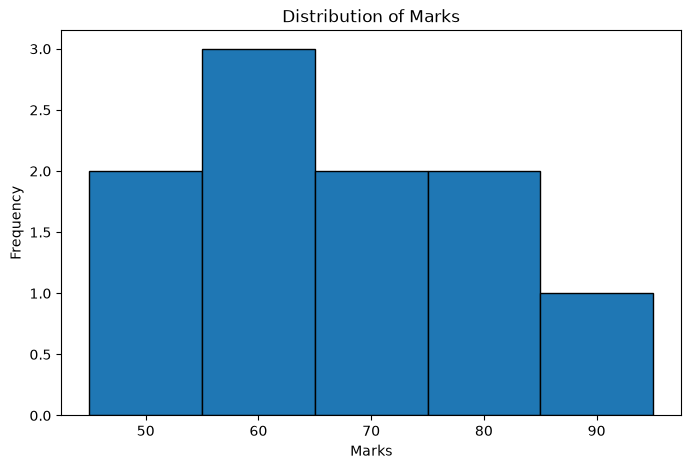

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(marks, bins=5, edgecolor="black")
plt.title("Distribution of Marks")
plt.xlabel("Marks")
plt.ylabel("Frequency")
plt.show()


## 20. Box plot

A box plot visually summarizes the five-number summary and can help identify possible outliers.


C:\Users\zeesh\AppData\Local\Temp\ipykernel_24444\2188880427.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(marks, vert=False)


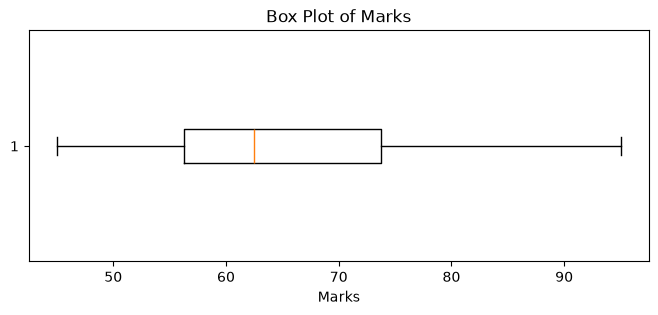

In [41]:
plt.figure(figsize=(8, 3))
plt.boxplot(marks, vert=False)
plt.title("Box Plot of Marks")
plt.xlabel("Marks")
plt.show()


## 21. Bar chart of frequencies


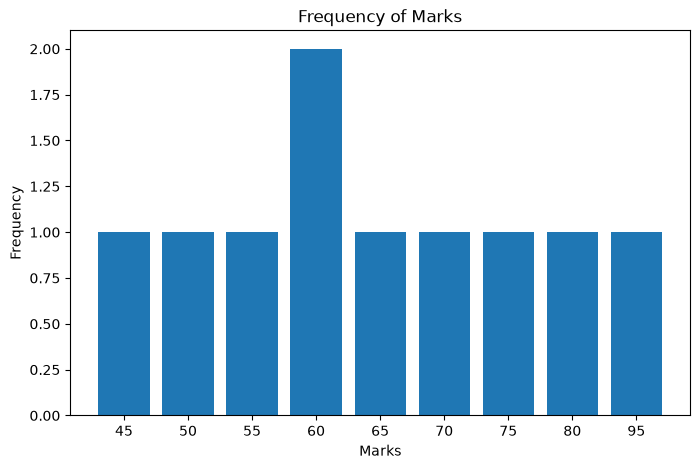

In [42]:
plt.figure(figsize=(8, 5))
plt.bar(frequency_table.index.astype(str), frequency_table.values)
plt.title("Frequency of Marks")
plt.xlabel("Marks")
plt.ylabel("Frequency")
plt.show()


## 22. Effect of an outlier

Let's compare the original data with a dataset containing a very large value.


In [43]:
original = [20, 21, 22, 23, 24]
with_outlier = [20, 21, 22, 23, 24, 100]

print("Original mean:", statistics.mean(original))
print("Original median:", statistics.median(original))

print("\nWith outlier mean:", statistics.mean(with_outlier))
print("With outlier median:", statistics.median(with_outlier))


Original mean: 22
Original median: 22

With outlier mean: 35
With outlier median: 22.5


The example demonstrates why the median can be more resistant to an extreme observation than the mean.


## 23. Compare two datasets with the same mean

Two datasets can have the same mean but different spread.


In [44]:
dataset_a = [48, 49, 50, 51, 52]
dataset_b = [10, 30, 50, 70, 90]

print("Mean A:", statistics.mean(dataset_a))
print("Mean B:", statistics.mean(dataset_b))

print("SD A:", statistics.pstdev(dataset_a))
print("SD B:", statistics.pstdev(dataset_b))


Mean A: 50
Mean B: 50
SD A: 1.4142135623730951
SD B: 28.284271247461902


## 24. Skewness intuition

A right-skewed distribution has a longer tail toward larger values.

A left-skewed distribution has a longer tail toward smaller values.

Mean and median can provide clues about skewness, but they should not be treated as a complete test of distribution shape.


## 25. Pandas descriptive summary

Pandas can quickly produce a statistical summary for numerical columns.


In [45]:
df = pd.DataFrame({
    "marks": marks,
    "hours_studied": [2, 2, 3, 3, 4, 4, 5, 5, 6, 7]
})

print(df.describe())


           marks  hours_studied
count  10.000000       10.00000
mean   65.500000        4.10000
std    14.990738        1.66333
min    45.000000        2.00000
25%    56.250000        3.00000
50%    62.500000        4.00000
75%    73.750000        5.00000
max    95.000000        7.00000


## 26. Applying descriptive statistics column by column


In [46]:
print("Mean:")
print(df.mean(numeric_only=True))

print("\nMedian:")
print(df.median(numeric_only=True))

print("\nStandard deviation:")
print(df.std(numeric_only=True))


Mean:
marks            65.5
hours_studied     4.1
dtype: float64

Median:
marks            62.5
hours_studied     4.0
dtype: float64

Standard deviation:
marks            14.990738
hours_studied     1.663330
dtype: float64


## 27. A complete descriptive-statistics workflow

Raw Data
   ↓
Check the observations
   ↓
Sort / organize where needed
   ↓
Central tendency
   ↓
Dispersion
   ↓
Quartiles / percentiles
   ↓
Frequency distribution
   ↓
Visualization
   ↓
Interpretation


## 28. Final summary

Important formulas:

Mean = Σx / n

Range = Maximum − Minimum

Population Variance = Σ(x − μ)² / N

Sample Variance = Σ(x − x̄)² / (n − 1)

Standard Deviation = √Variance

**IQR = Q3 − Q1**

**Quartile Deviation = (Q3 − Q1) / 2**

**MAD = Σ|x − x̄| / n**

### Points to remember

- Mean uses every observation.
- Median requires ordered data.
- Mode is based on frequency.
- Range uses only the minimum and maximum.
- Variance is measured in squared units.
- Standard deviation returns to the original unit.
- IQR describes the middle 50% of observations.
- A box plot is based on quartiles and the median.
- Histograms describe numerical distributions.
- Always distinguish population statistics from sample statistics.


## References / Further Reading

- [GeeksforGeeks — Descriptive Statistics](https://www.geeksforgeeks.org/maths/descriptive-statistics/)
- [GeeksforGeeks — Mean, Median and Mode](https://www.geeksforgeeks.org/maths/mean-median-mode/)
- [Khan Academy — Summarizing Quantitative Data](https://www.khanacademy.org/math/statistics-probability/summarizing-quantitative-data)
- [NIST/SEMATECH — e-Handbook of Statistical Methods](https://www.itl.nist.gov/div898/handbook/)
